# Week 9 Progress: Core Results for the Paper

This notebook produces the small, focused set of results the Week 9 assignment asks for, using our final defense (feature-agnostic behavioral trust plus coordinate-wise median). The full defense development lives in the week 8 folder; here we run only the core evidence the paper needs: whether the attack works, whether the defense reduces the backdoor effect, and whether clean accuracy is preserved.

**What the assignment asks for, and where it is in this notebook:**
1. Core experiments (honest baseline, attack, defense, plus one optional ablation): Sections 3 to 4.
2. One main result table with the key metrics: Section 5.
3. One main figure supporting the paper claim: Section 6.
4. One small sensitivity check: Section 7.
5. A short written summary: Section 8.
6. Background-reading notes (computational overhead, false positives): Section 9.

**A note on our setup vs the assignment template.** The template refers to a single poisoned "Client 5." Our final design uses **two** compromised clients (C9 and C10, a 20% compromise rate), so wherever the template says "Client 5 trust/weight" we report the trust of both attacker clients.

**Who wrote what (individual contributions), tagged in each code cell header:**
- **(Will)** Sections 1 to 2: data loading, preprocessing, and the attack setup.
- **(Dilpreet)** Sections 3 to 4: the model, the defense, and the core experiments.
- **(Cole)** Sections 5 to 9: the main table, the main figure, the sensitivity check, and the written summary.

Everything runs top to bottom on the real Aissou et al. 2022 GPS spoofing dataset in the repo.

## 1. Data and preprocessing (Will)

Standard pipeline: drop duplicates, make the label binary (authentic vs spoofed), remove conflicting rows after binarization, drop the identifier columns. We take a 150k-row sample, hold out a test set, and carve a small clean root set from the training pool for the server to use (never from the test set).

In [1]:
# ======================================================================
# (Will)  Load the GPS dataset, clean it, and split it.
# ======================================================================
import copy, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)
def reseed(s=SEED): np.random.seed(s); torch.manual_seed(s)   # each experiment starts identically
RESULTS = Path('results'); RESULTS.mkdir(exist_ok=True)

def resolve_data():
    # this notebook sits one level under weeks/, so ../week07 is the dataset
    for p in ['../week07-first-working-version/A DATASET for GPS Spoofing Detection on Unmanned Aerial System/GPS_Data_Simplified_2D_Feature_Map.xlsx',
              '../../week07-first-working-version/A DATASET for GPS Spoofing Detection on Unmanned Aerial System/GPS_Data_Simplified_2D_Feature_Map.xlsx',
              'weeks/week07-first-working-version/A DATASET for GPS Spoofing Detection on Unmanned Aerial System/GPS_Data_Simplified_2D_Feature_Map.xlsx']:
        if Path(p).exists(): return p
    raise FileNotFoundError('GPS dataset not found')

N_BENIGN, N_SPOOFED, SERVER_ROOT = 90_000, 60_000, 6_000
raw = pd.read_excel(resolve_data(), engine='openpyxl')
raw = raw.drop_duplicates()
raw['label'] = (raw['Output'] != 0).astype(int)
fc = [c for c in raw.columns if c not in ('Output', 'label')]
cmask = raw.duplicated(subset=fc, keep=False)
grp = raw[cmask].groupby(fc)['label'].nunique()
keys = grp[grp > 1].index
if len(keys):
    ck = pd.DataFrame(keys.tolist(), columns=fc)
    isc = raw[fc].apply(tuple, axis=1).isin([tuple(k) for k in ck.itertuples(index=False)])
    raw = raw[~isc]
df = raw.drop(columns=['PRN', 'RX', 'TOW', 'Output'])
FEATURES = [c for c in df.columns if c != 'label']

b = df[df.label == 0].sample(N_BENIGN, random_state=SEED)
s = df[df.label == 1].sample(N_SPOOFED, random_state=SEED)
sub = pd.concat([b, s]).sample(frac=1, random_state=SEED).reset_index(drop=True)
X = sub[FEATURES].values.astype(np.float32); y = sub['label'].values.astype(np.int64)
X_tr_all, X_test, y_tr_all, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=y)
X_pool, X_root, y_pool, y_root = train_test_split(X_tr_all, y_tr_all, test_size=SERVER_ROOT, random_state=SEED, stratify=y_tr_all)
scaler = StandardScaler()
X_pool_sc = scaler.fit_transform(X_pool).astype(np.float32)
X_root_sc = scaler.transform(X_root).astype(np.float32)
X_test_sc = scaler.transform(X_test).astype(np.float32)
print(f'features ({len(FEATURES)}): {FEATURES}')
print(f'client pool: {len(y_pool):,}   server root: {len(y_root):,}   test: {len(y_test):,}')

features (10): ['DO', 'PD', 'CP', 'EC', 'LC', 'PC', 'PIP', 'PQP', 'TCD', 'CN0']
client pool: 114,000   server root: 6,000   test: 30,000


## 2. The attack setup (Will)

Ten UAV clients, IID split, last two (C9, C10) compromised. The attack has three levers from our threat model: data poisoning (40% of the attacker's spoofed rows get a trigger on the CN0 feature and are relabeled authentic), model-replacement scaling (the attacker scales up its update so it survives averaging, tuned to keep clean accuracy normal so the backdoor stays stealthy), and accuracy inflation (the attacker reports a fake 0.99 accuracy in the accuracy-weighted case). The probe features for the defense are chosen with Cohen's d only to drop useless features, not to guess the trigger.

In [2]:
# ======================================================================
# (Will)  Client split, probe features, and the attack (poisoning + trigger).
# ======================================================================
N_CLIENTS, N_ATTACK, VAL_FRAC = 10, 2, 0.15
CN0 = FEATURES.index('CN0')
def scaled_val(fi, rv): return (rv - scaler.mean_[fi]) / scaler.scale_[fi]
TRIG_CN0 = scaled_val(CN0, np.percentile(X_pool[y_pool==0, CN0], 75))   # trigger = benign 75th pct of CN0

# Cohen's d: keep only features with real class signal (drop near-zero ones)
def cohens_d():
    out = {}
    for i, f in enumerate(FEATURES):
        a0, a1 = X_pool[y_pool==0, i], X_pool[y_pool==1, i]
        out[f] = abs(a0.mean()-a1.mean()) / np.sqrt((a0.var()+a1.var())/2 + 1e-8)
    return out
DV = cohens_d()
PROBE_FEATS = [f for f in FEATURES if DV[f] >= 0.05]
BENIGN_HIGH = {f: scaled_val(FEATURES.index(f), np.percentile(X_pool[y_pool==0, FEATURES.index(f)], 75)) for f in PROBE_FEATS}

def iid_split(Xs, ys, seed=SEED):
    rng = np.random.default_rng(seed)
    bi, si = np.where(ys==0)[0], np.where(ys==1)[0]; rng.shuffle(bi); rng.shuffle(si); cl=[]
    for bb, ss in zip(np.array_split(bi, N_CLIENTS), np.array_split(si, N_CLIENTS)):
        idx = np.concatenate([bb, ss]); rng.shuffle(idx); Xc, yc = Xs[idx], ys[idx]
        Xt, Xv, yt, yv = train_test_split(Xc, yc, test_size=VAL_FRAC, random_state=seed, stratify=yc)
        cl.append({'Xt':Xt,'yt':yt,'Xv':Xv,'yv':yv})
    return cl
CLIENTS = iid_split(X_pool_sc, y_pool)

def poison(base, rate, fidx, tval, seed=SEED):
    out = list(base)
    for i in range(N_CLIENTS - N_ATTACK, N_CLIENTS):
        c = base[i]
        def _p(Xa, ya, sd):
            Xa, ya = Xa.copy(), ya.copy(); rng = np.random.default_rng(sd)
            idx = np.where(ya==1)[0]; ch = rng.choice(idx, size=int(len(idx)*rate), replace=False)
            Xa[ch, fidx] = tval; ya[ch] = 0; return Xa, ya
        Xt, yt = _p(c['Xt'], c['yt'], seed+i); Xv, yv = _p(c['Xv'], c['yv'], seed+i+100)
        out[i] = {'Xt':Xt,'yt':yt,'Xv':Xv,'yv':yv}
    return out

# triggered test set: real spoofed rows with the trigger stamped on, true label kept spoofed
m = y_test == 1
X_TRIG = X_test_sc[m].copy(); X_TRIG[:, CN0] = TRIG_CN0
print(f'10 clients, 2 attackers (C9, C10). CN0 trigger (scaled) = {TRIG_CN0:.3f}')
print(f'probe features: {PROBE_FEATS}')
print(f'triggered test rows: {int(m.sum()):,} spoofed rows with the trigger applied')

10 clients, 2 attackers (C9, C10). CN0 trigger (scaled) = 0.738
probe features: ['DO', 'PD', 'CP', 'EC', 'LC', 'PC', 'TCD', 'CN0']
triggered test rows: 12,000 spoofed rows with the trigger applied


## 3. Model and defense (Dilpreet)

A small binary DNN (about 13k parameters). The defense has two server-side layers. Coordinate-wise median resists an attacker that scales up its update. The behavioral-trust score is our contribution: for every client, on its own clean root data, the server checks basic accuracy and then, for each discriminative feature, whether the client still detects spoofing when that feature is pushed to a benign-looking value. A client that is unusually bad on any single feature (relative to the group, using a robust median and MAD) is flagged as suspicious and its update is scaled toward zero. Nothing here reads a client's self-reported accuracy, which is why accuracy inflation does not help the attacker.

In [3]:
# ======================================================================
# (Dilpreet)  The model, the FL loop, and the behavioral-trust defense.
# ======================================================================
BETA, EMA, FL_ROUNDS, LOCAL_EPOCHS, BATCH = 2.0, 0.5, 12, 3, 512
D = len(FEATURES)

class BinaryDNN(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(d,64), nn.ReLU(), nn.Dropout(0.2),
                                 nn.Linear(64,32), nn.ReLU(), nn.Dropout(0.2),
                                 nn.Linear(32,16), nn.ReLU(), nn.Linear(16,1))
    def forward(self, x): return self.net(x).squeeze(-1)

def loader(X, y): return DataLoader(TensorDataset(torch.FloatTensor(X), torch.FloatTensor(y.astype(np.float32))), batch_size=BATCH, shuffle=True)
def train_local(mdl, X, y):
    ld = loader(X, y); opt = torch.optim.Adam(mdl.parameters(), lr=1e-3); crit = nn.BCEWithLogitsLoss(); mdl.train()
    for _ in range(LOCAL_EPOCHS):
        for xb, yb in ld: opt.zero_grad(); crit(mdl(xb), yb).backward(); opt.step()
def preds(mdl, X):
    mdl.eval()
    with torch.no_grad(): return (mdl(torch.FloatTensor(X)) > 0).long().numpy()
def acc(mdl, X, y): return (preds(mdl, X) == y).mean()
def get_p(mdl): return [p.data.clone() for p in mdl.parameters()]
def set_p(mdl, ps):
    for p, v in zip(mdl.parameters(), ps): p.data.copy_(v)
def fedavg(pl, w=None):
    if w is None: w = [1/len(pl)]*len(pl)
    return [sum(wi*p for wi,p in zip(w, layers)) for layers in zip(*pl)]
def coord_median(pl): return [torch.stack(list(layers),0).median(0).values for layers in zip(*pl)]

_root_spoof = X_root_sc[y_root == 1]
PROBE_SLICES = {}
for f in PROBE_FEATS:
    fi = FEATURES.index(f); Xp = _root_spoof.copy(); Xp[:, fi] = BENIGN_HIGH[f]; PROBE_SLICES[f] = Xp

def behavioral_trust(models):
    clean = np.array([acc(mm, X_root_sc, y_root) for mm in models])
    detect = np.zeros((len(models), len(PROBE_FEATS)))
    for j, f in enumerate(PROBE_FEATS):
        Xp = PROBE_SLICES[f]
        for i, mm in enumerate(models): detect[i, j] = (preds(mm, Xp) == 1).mean()
    med = np.median(detect, axis=0); mad = np.median(np.abs(detect - med), axis=0) + 1e-6
    susp = np.maximum(0.0, (med - detect) / mad).max(axis=1)
    if clean.max() < 0.55 or (clean.max()-clean.min()) < 1e-3:
        return np.ones(len(models))/len(models)
    r = clean * np.exp(-BETA * susp)
    return r/r.sum() if r.sum() > 1e-9 else np.ones(len(models))/len(models)

BOOST = 3.0
def run_fl(clist, defense=None, acc_weighted=False, fake=False, boost=1.0, ref=None, tag=''):
    reseed()
    g = BinaryDNN(D); trust_hist = []; prev = None
    for _ in range(FL_ROUNDS):
        gp = get_p(g); locs, models, reported = [], [], []
        for i, c in enumerate(clist):
            mm = copy.deepcopy(g); train_local(mm, c['Xt'], c['yt']); models.append(mm)
            lp = get_p(mm)
            if boost != 1.0 and i >= N_CLIENTS - N_ATTACK:
                lp = [gg + boost*(pp-gg) for gg, pp in zip(gp, lp)]
            locs.append(lp)
            va = acc(mm, c['Xv'], c['yv']); reported.append(0.99 if (fake and i >= N_CLIENTS-N_ATTACK) else va)
        if defense in ('trust', 'full'):
            t = behavioral_trust(models)
            if prev is not None: t = EMA*t + (1-EMA)*prev
            prev = t; trust_hist.append(t.copy())
            scaled = [[gg + N_CLIENTS*tt*(pp-gg) for gg, pp in zip(gp, params)] for tt, params in zip(t, locs)]
            new = coord_median(scaled) if defense == 'full' else fedavg(scaled)
        elif defense == 'median':
            new = coord_median(locs)
        elif acc_weighted:
            tot = sum(reported); new = fedavg(locs, [a/tot for a in reported])
        else:
            new = fedavg(locs)
        set_p(g, new)
    p = preds(g, X_test_sc); ca = (p == y_test).mean(); sr = p[y_test==1].mean()
    bsr = (preds(g, X_TRIG) == 0).mean(); lift = (bsr - ref) if ref is not None else float('nan')
    print(f'[{tag}] clean_acc={ca:.4f}  spoof_recall={sr:.4f}  BSR={bsr:.4f}  lift={lift:+.4f}')
    return dict(clean=ca, recall=sr, bsr=bsr, lift=lift, trust=trust_hist)
print('model + defense ready')

model + defense ready


## 4. Core experiments (Dilpreet)

The three required cases plus one optional ablation:
- **Honest FedAvg**: all clients honest, the normal reference. This also fixes the honest backdoor success rate that lift is measured against (it is not zero, because the trigger value already looks benign).
- **Attack (FedAvg)**: the two clients poison and scale their updates.
- **Attack + inflation (accuracy-weighted)**: same attack, and the attackers also report a fake 0.99 accuracy to grab more aggregation weight. This is the worst case.
- **Median-only (optional ablation)**: robust aggregation without the trust probing.
- **Full defense**: trust probing plus coordinate-wise median.

In [4]:
# ======================================================================
# (Dilpreet)  Run the core experiments.
# ======================================================================
r_honest = run_fl(CLIENTS, defense=None, ref=0.0, tag='Honest FedAvg')
H = r_honest['bsr']; r_honest['lift'] = 0.0
pois = poison(CLIENTS, 0.40, CN0, TRIG_CN0)
r_attack   = run_fl(pois, defense=None,                 boost=BOOST, ref=H, tag='Attack (FedAvg)')
r_inflate  = run_fl(pois, acc_weighted=True, fake=True, boost=BOOST, ref=H, tag='Attack + inflation (Acc-Weighted)')
r_median   = run_fl(pois, defense='median',             boost=BOOST, ref=H, tag='Median-only (ablation)')
r_defense  = run_fl(pois, defense='full',               boost=BOOST, ref=H, tag='Full defense')
print(f'\nHonest backdoor success rate (lift reference) = {H:.4f}')

[Honest FedAvg] clean_acc=0.7138  spoof_recall=0.5447  BSR=0.6600  lift=+0.6600
[Attack (FedAvg)] clean_acc=0.6990  spoof_recall=0.3977  BSR=0.8966  lift=+0.2366
[Attack + inflation (Acc-Weighted)] clean_acc=0.6941  spoof_recall=0.3758  BSR=0.9429  lift=+0.2829
[Median-only (ablation)] clean_acc=0.7135  spoof_recall=0.5152  BSR=0.7154  lift=+0.0554
[Full defense] clean_acc=0.7095  spoof_recall=0.5387  BSR=0.6412  lift=-0.0188

Honest backdoor success rate (lift reference) = 0.6600


## 5. Main result table (Cole)

One table comparing the main cases on clean accuracy, spoofing recall, backdoor success rate (BSR), backdoor lift, and attacker trust/weight. Backdoor lift is BSR minus the honest baseline, so it isolates the extra harm the attacker causes. The attacker trust/weight column shows the aggregate influence the two compromised clients (C9, C10) hold: uniform under plain FedAvg, inflated under accuracy weighting, and driven to zero by the full defense.

In [5]:
# ======================================================================
# (Cole)  Build the main results table.
# ======================================================================
att_trust_defense = float(np.array(r_defense['trust'])[:, N_CLIENTS-N_ATTACK:].mean())
rows = [
    ('Honest FedAvg',                    r_honest,  'n/a (no attacker)'),
    ('Attack (FedAvg)',                  r_attack,  '0.100 (uniform)'),
    ('Attack + inflation (Acc-Weighted)',r_inflate, 'inflated above 0.100 (fake 0.99)'),
    ('Median-only (ablation)',           r_median,  'n/a (no weighting)'),
    ('Full defense',                     r_defense, f'{att_trust_defense:.3f} (suppressed)'),
]
main = pd.DataFrame([{
    'Case': n,
    'Clean Acc': round(r['clean'],4),
    'Spoof Recall': round(r['recall'],4),
    'BSR': round(r['bsr'],4),
    'Backdoor Lift': round(r['lift'],4),
    'Attacker Trust/Weight': w,
} for n, r, w in rows])
print(main.to_string(index=False))
main.to_csv(RESULTS/'main_results_table.csv', index=False)

                             Case  Clean Acc  Spoof Recall    BSR  Backdoor Lift            Attacker Trust/Weight
                    Honest FedAvg     0.7138        0.5447 0.6600         0.0000                n/a (no attacker)
                  Attack (FedAvg)     0.6990        0.3977 0.8966         0.2366                  0.100 (uniform)
Attack + inflation (Acc-Weighted)     0.6941        0.3758 0.9429         0.2829 inflated above 0.100 (fake 0.99)
           Median-only (ablation)     0.7135        0.5152 0.7154         0.0554               n/a (no weighting)
                     Full defense     0.7095        0.5387 0.6412        -0.0188               0.000 (suppressed)


**What the table shows.** The attack raises the backdoor success rate far above the honest baseline (lift about +0.24), and accuracy inflation makes it worse (about +0.28) by handing the attackers more aggregation weight. The full defense drives the lift back to about zero, so the attacker gains no advantage over an honest model, while clean accuracy stays essentially unchanged (about 0.71) and spoofing recall is restored. The attacker trust column tells the same story from the aggregation side: the two compromised clients hold uniform weight under plain FedAvg, an inflated share under accuracy weighting, and near zero under the defense. Median-only helps but leaves a residual lift, which is why the trust layer is needed on top.

## 6. Main figure (Cole)

The main figure is backdoor lift before and after the defense. Two supporting figures follow: attacker trust across rounds (which shows the defense identifying the compromised clients) and BSR by experiment (the same story in raw terms).

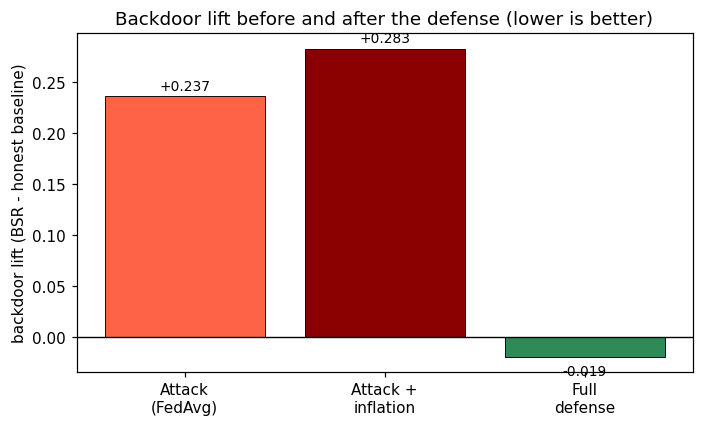

In [6]:
# ======================================================================
# (Cole)  Main figure: backdoor lift before and after defense.
# ======================================================================
labels = ['Attack\n(FedAvg)', 'Attack +\ninflation', 'Full\ndefense']
lifts  = [r_attack['lift'], r_inflate['lift'], r_defense['lift']]
colors = ['tomato', 'darkred', 'seagreen']
fig, ax = plt.subplots(figsize=(6.5,4))
ax.bar(labels, lifts, color=colors, edgecolor='black', lw=0.6)
ax.axhline(0, color='black', lw=0.9)
ax.set_ylabel('backdoor lift (BSR - honest baseline)')
ax.set_title('Backdoor lift before and after the defense (lower is better)')
for i, v in enumerate(lifts): ax.text(i, v + (0.006 if v>=0 else -0.018), f'{v:+.3f}', ha='center', fontsize=9)
fig.tight_layout(); fig.savefig(RESULTS/'main_figure_lift.png', dpi=120); plt.show()

**Caption.** Backdoor lift (backdoor success rate minus the honest baseline) for the two attack cases and the full defense. The attack adds a large positive lift, accuracy inflation adds more, and the defense removes it entirely, driving the lift to approximately zero. This is the core paper claim: the attack works, and the defense neutralizes it.

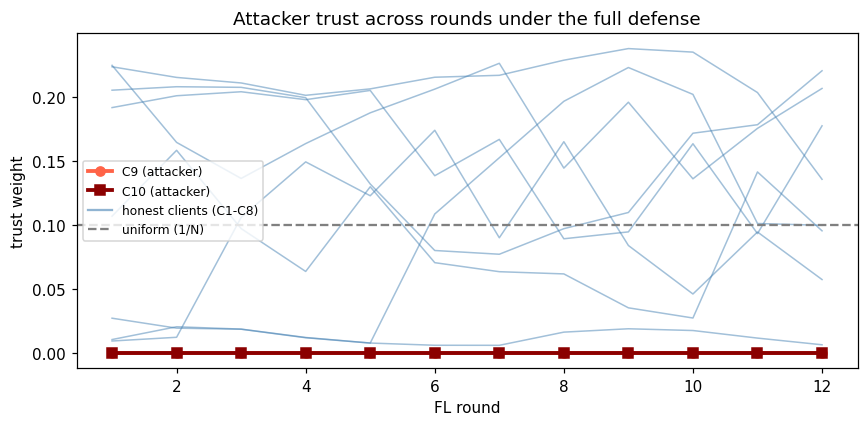

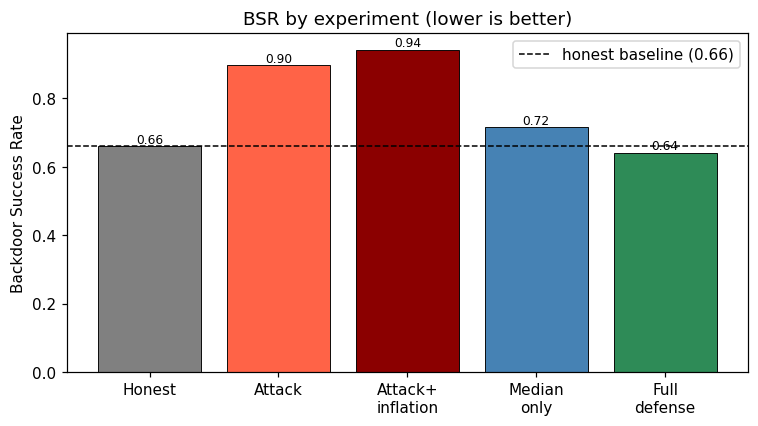

In [7]:
# ======================================================================
# (Cole)  Supporting figure 1: attacker trust across rounds (attribution).
# ======================================================================
a = np.array(r_defense['trust'])
fig, ax = plt.subplots(figsize=(8,4))
for i in range(N_CLIENTS-N_ATTACK):
    ax.plot(range(1,len(a)+1), a[:,i], color='steelblue', alpha=0.5, lw=1)
ax.plot(range(1,len(a)+1), a[:,-2], color='tomato', lw=2.5, marker='o', label='C9 (attacker)')
ax.plot(range(1,len(a)+1), a[:,-1], color='darkred', lw=2.5, marker='s', label='C10 (attacker)')
ax.plot([], [], color='steelblue', alpha=0.6, label='honest clients (C1-C8)')
ax.axhline(1/N_CLIENTS, ls='--', color='gray', label='uniform (1/N)')
ax.set_xlabel('FL round'); ax.set_ylabel('trust weight')
ax.set_title('Attacker trust across rounds under the full defense')
ax.legend(fontsize=8); fig.tight_layout(); fig.savefig(RESULTS/'support_trust_rounds.png', dpi=120); plt.show()

# Supporting figure 2: BSR by experiment
labs2 = ['Honest','Attack','Attack+\ninflation','Median\nonly','Full\ndefense']
bsrs  = [r_honest['bsr'], r_attack['bsr'], r_inflate['bsr'], r_median['bsr'], r_defense['bsr']]
cols2 = ['gray','tomato','darkred','steelblue','seagreen']
fig, ax = plt.subplots(figsize=(7,4))
ax.bar(labs2, bsrs, color=cols2, edgecolor='black', lw=0.6)
ax.axhline(H, ls='--', color='black', lw=1, label=f'honest baseline ({H:.2f})')
ax.set_ylabel('Backdoor Success Rate'); ax.set_title('BSR by experiment (lower is better)')
for i, v in enumerate(bsrs): ax.text(i, v+0.01, f'{v:.2f}', ha='center', fontsize=8)
ax.legend(); fig.tight_layout(); fig.savefig(RESULTS/'support_bsr_by_experiment.png', dpi=120); plt.show()

## 7. Sensitivity check (Cole)

One small sensitivity test: vary the attacker poison ratio (30, 40, 50 percent) with the full defense on, everything else fixed. This checks that the result is not a lucky artifact of one setting.

In [8]:
# ======================================================================
# (Cole)  Sensitivity: poison ratio vs backdoor lift under the full defense.
# ======================================================================
sens_rows = []
for pr in (0.30, 0.40, 0.50):
    rr = r_defense if pr == 0.40 else run_fl(poison(CLIENTS, pr, CN0, TRIG_CN0), defense='full', boost=BOOST, ref=H, tag=f'Full defense, poison={pr:.0%}')
    sens_rows.append({'Poison Ratio': f'{int(pr*100)}%', 'Clean Acc': round(rr['clean'],4),
                      'Spoof Recall': round(rr['recall'],4), 'BSR': round(rr['bsr'],4),
                      'Backdoor Lift': round(rr['lift'],4)})
sens = pd.DataFrame(sens_rows)
print(sens.to_string(index=False))
sens.to_csv(RESULTS/'sensitivity_table.csv', index=False)

[Full defense, poison=30%] clean_acc=0.7092  spoof_recall=0.5357  BSR=0.6419  lift=-0.0181
[Full defense, poison=50%] clean_acc=0.7095  spoof_recall=0.5373  BSR=0.6407  lift=-0.0193
Poison Ratio  Clean Acc  Spoof Recall    BSR  Backdoor Lift
         30%     0.7092        0.5357 0.6419        -0.0181
         40%     0.7095        0.5387 0.6412        -0.0188
         50%     0.7095        0.5373 0.6407        -0.0193


**What the sensitivity check shows.** Across poison ratios from 30 to 50 percent, the defended backdoor lift stays flat and near zero. The defense does not depend on the attacker choosing one particular poison rate, so the main result is robust to this parameter.

## 8. Written summary (Cole)

**Experiments completed.** Honest FedAvg baseline, the attack under plain FedAvg, the attack under accuracy-weighted aggregation with accuracy inflation, a median-only ablation, and the full defense (behavioral trust plus coordinate-wise median). A poison-ratio sensitivity check was also completed.

**Key parameter settings.** 10 clients, 2 attackers (C9, C10, a 20% compromise rate), IID split, 150,000-row sample (60% authentic, 40% spoofed), 12 FL rounds, 3 local epochs, batch size 512, seed 42. Attack: 40% poison rate, CN0 trigger at the benign 75th percentile, model-replacement scaling factor 3, fake reported accuracy 0.99 in the inflation case. Defense: behavioral-trust sharpness beta 2.0, trust smoothing 0.5, server root set of 6,000 clean rows.

**What the main table shows.** The attack raises the backdoor success rate well above the honest baseline (lift about +0.24, and about +0.28 with inflation), while the full defense drives the lift back to about zero. Clean accuracy stays around 0.71 throughout and spoofing recall is restored. The attacker trust column shows the two compromised clients driven from uniform (or inflated) weight down to near zero.

**What the main figure shows.** Backdoor lift before and after the defense: large and positive under attack, approximately zero after the defense.

**Did the defense reduce BSR / backdoor lift?** Yes. Backdoor lift drops from about +0.24 (attack) and +0.28 (attack plus inflation) to about zero under the full defense. The attacker gains no advantage over an honest model.

**Did clean accuracy stay reasonable?** Yes. Clean accuracy under the defense (about 0.71) matches the honest baseline within noise, and spoofing recall is nearly fully restored, so the defense does not trade away normal detection.

**What remains unfinished.** The base detector is only moderately strong on this simplified dataset (spoofing recall about 0.54 with no trigger), which is why lift, not raw accuracy, is the primary metric. We have not yet tested an adaptive attacker that specifically tries to evade the trust probe (as opposed to switching trigger features, which we did test elsewhere). Non-IID client data and a larger fleet are also left for later.

## 9. Background-reading notes (no separate deliverable)

Brief notes to keep on hand, per the assignment.

**Computational overhead.** The model is tiny (about 3,300 parameters, roughly 13 KB per update), so federated communication is light (a few MB for a full run). The defense runs entirely on the server and adds only tens of milliseconds per round (forward-pass probing on a small root set plus a coordinate-wise median), which is a small fraction of the round time; local client training dominates. Complexity of the added server work is linear in the number of clients and probe features. A full breakdown lives in the week 8 cost-analysis folder.

**False-positive reporting.** For a trust-based defense, the false-positive question has two parts. Defense-level: does the trust mechanism wrongly punish an honest client? Because trust is a continuous per-round weight rather than a hard flag, the honest metric is that no honest client is ever fully excluded (only the attackers are driven to zero), though one honest client can be persistently down-weighted, which we would disclose. Detector-level: how often does the model call an authentic signal spoofed (a false alarm)? The full defense keeps that rate at the honest baseline level. A fuller discussion lives in the week 8 final folder.